# Task1 - Environment Setup & Data Loading

In [19]:
#Set up Python env (pandas, numpy, matplotlib/seaborn).
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
#Load these CSVs into DataFrames: drivers.csv, races.csv, results.csv, constructors.csv, circuits.csv
df_drivers = pd.read_csv('../data/drivers.csv')
df_races = pd.read_csv('../data/races.csv')
df_results = pd.read_csv('../data/results.csv')
df_constructors = pd.read_csv('../data/constructors.csv')
df_circuits = pd.read_csv('../data/circuits.csv')

In [21]:
#Print .shape and .dtypes for each DataFrame
dfs = {
    "drivers": df_drivers,
    "races": df_races,
    "results": df_results,
    "constructors": df_constructors,
    "circuits": df_circuits
}

for name, df in dfs.items():
    print(f"===== {name} =====")
    print("shape:", df.shape)
    print(df.dtypes)
    print()

===== drivers =====
shape: (861, 9)
driverId       int64
driverRef        str
number           str
code             str
forename         str
surname          str
dob              str
nationality      str
url              str
dtype: object

===== races =====
shape: (1125, 18)
raceId         int64
year           int64
round          int64
circuitId      int64
name             str
date             str
time             str
url              str
fp1_date         str
fp1_time         str
fp2_date         str
fp2_time         str
fp3_date         str
fp3_time         str
quali_date       str
quali_time       str
sprint_date      str
sprint_time      str
dtype: object

===== results =====
shape: (26759, 18)
resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number                 str
grid                 int64
position               str
positionText           str
positionOrder        int64
points             float64
laps                 i

# Task2 - Data Cleaning

In [22]:
# Identify missing/placeholder values (e.g. '\N') in results.csv (columns: milliseconds, fastestLapTime, fastestLapSpeed) and drivers.csv (dob, nationality)
results_cols = ['milliseconds', 'fastestLapTime', 'fastestLapSpeed']
df_results.replace('\\N', np.nan, inplace=True)
for c in results_cols:
    print(f'results missing {c} counts : {df_results[c].isnull().sum()}')

drivers_cols = ['dob', 'nationality']
df_drivers.replace('\\N', np.nan, inplace=True)
for c in drivers_cols:
    print(f'drivers missing {c} counts : {df_drivers[c].isnull().sum()}')

results missing milliseconds counts : 19079
results missing fastestLapTime counts : 18507
results missing fastestLapSpeed counts : 18507
drivers missing dob counts : 0
drivers missing nationality counts : 0


In [23]:
# Report count of missing values per column BEFORE and AFTER cleaning. Convert data types where needed (e.g. dob to datetime, milliseconds to numeric)
missing_before_drivers = df_drivers.isnull().sum()
missing_before_results = df_results.isnull().sum()

print("=== BEFORE cleaning ===")
print("=== drivers ===")
print(missing_before_drivers)
print("=== results ===")
print(missing_before_results)

df_drivers.replace('\\N', np.nan, inplace=True)
df_results.replace('\\N', np.nan, inplace=True)

df_drivers['dob'] = pd.to_datetime(df_drivers['dob'], errors='coerce')
df_results['milliseconds'] = pd.to_numeric(df_results['milliseconds'], errors='coerce')

print(df_drivers['dob'].dtype)       
print(df_results['milliseconds'].dtype) 

missing_after_drivers = df_drivers.isnull().sum()
missing_after_results = df_results.isnull().sum()
print("=== AFTER cleaning ===")
print("=== drivers ===")
print(missing_after_drivers)
print("=== results ===")
print(missing_after_results)

=== BEFORE cleaning ===
=== drivers ===
driverId         0
driverRef        0
number         802
code           757
forename         0
surname          0
dob              0
nationality      0
url              0
dtype: int64
=== results ===
resultId               0
raceId                 0
driverId               0
constructorId          0
number                 6
grid                   0
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
statusId               0
dtype: int64
datetime64[us]
float64
=== AFTER cleaning ===
=== drivers ===
driverId         0
driverRef        0
number         802
code           757
forename         0
surname          0
dob              0
nationality      0
url              0
dtype: int64
=== results ===
resultId               0
raceId    

# Task3 - Merge Master Dataset

In [ ]:
# Merge results + races + drivers + constructors into one DataFrame with at least: raceId, year, round, driverName (full name), constructorName, grid, position, points, statusId
df_drivers['full_name'] = df_drivers[['forename', 'surname']].agg(' '.join, axis=1)
drivers_subset = df_drivers[['driverId', 'full_name']]
races_subset = df_races[['raceId', 'year', 'round']]
results_subset = df_results[['raceId', 'driverId', 'constructorId', 'grid', 'position', 'points', 'statusId']]
constructors_subset = df_constructors[['constructorId', 'name']]

merged = results_subset.merge(drivers_subset, on = 'driverId', how = 'left') \
                        .merge(races_subset, on = 'raceId', how = 'left') \
                        .merge(constructors_subset, on = 'constructorId', how = 'left')

print(merged.shape)
print(merged.columns)
print(merged.head())

NameError: name 'df_drivers' is not defined

In [25]:
#Export result as merged_f1.csv.
merged.to_csv('../data/merged_f1.csv', index=False)

# Task4 - Top Drivers by Career Points

In [26]:
# Using groupby/aggregation, compute total career points per driver (all seasons, 1950-2020)
filtered = merged[(merged['year'] >= 1950) & (merged['year'] <= 2020)]
career = filtered.groupby('full_name')['points'].sum()
print(career)

full_name
Adolf Brudes           0.0
Adolfo Cruz            0.0
Adrian Sutil         124.0
Adrián Campos          0.0
Aguri Suzuki           8.0
                     ...  
Zsolt Baumgartner      1.0
Élie Bayol             2.0
Éric Bernard          10.0
Érik Comas             7.0
Óscar González         0.0
Name: points, Length: 850, dtype: float64


In [27]:
# Output a table of Top 10 drivers by total points, sorted descending
career_top_10 = career.sort_values(ascending=False).head(10)
print(career_top_10)

full_name
Lewis Hamilton        3778.0
Sebastian Vettel      3018.0
Fernando Alonso       1899.0
Kimi Räikkönen        1863.0
Nico Rosberg          1594.5
Michael Schumacher    1566.0
Valtteri Bottas       1512.0
Jenson Button         1235.0
Felipe Massa          1167.0
Max Verstappen        1162.0
Name: points, dtype: float64


# Task5 - Top Constructors by Decade

In [28]:
#  Compute number of race wins (position == 1) per constructor, grouped by decade (1950s, 1960s, ..., 2020s).
merged['decade'] = (merged['year'] // 10) * 10
wins = merged[merged['position'] == '1']
wins_by_decade = wins.groupby(['constructorId', 'decade']).size().reset_index(name='win_count')
print(wins_by_decade)

    constructorId  decade  win_count
0               1    1970         20
1               1    1980         56
2               1    1990         43
3               1    2000         41
4               1    2010         18
..            ...     ...        ...
77            196    1960          9
78            208    2010          2
79            211    2020          1
80            213    2020          1
81            214    2020          1

[82 rows x 3 columns]


In [29]:
# Output as a pivot table (rows = constructor, columns = decade, values = win count)
pivot = pd.pivot_table(
    wins,
    index = 'constructorId',
    columns = 'decade',
    values = 'position',
    aggfunc = 'count',
    fill_value = 0
)

print(pivot)

decade         1950  1960  1970  1980  1990  2000  2010  2020
constructorId                                                
1                 0     0    20    56    43    41    18     7
2                 0     0     0     0     0     1     0     0
3                 0     0     5    37    61    10     1     0
4                 0     0     1    14     0    20     0     0
5                 0     0     0     0     0     1     0     0
6                30    13    37    18    28    85    28    10
9                 0     0     0     0     0     6    56    60
11                0     2     0     0     0     1     0     0
17                0     0     0     0     3     1     0     0
22                0     0     0     2    25     0     0     0
23                0     0     0     0     0     8     0     0
24                0     0     0     0     1     0     0     0
25                0     0    21     2     0     0     0     0
27                0     0     4     4     1     0     0     0
32      

# Task6 - NumPy Statistics on Finishing Position

In [30]:
#  Pick 2 drivers (e.g. Lewis Hamilton vs Michael Schumacher)
LH = merged[merged['full_name'] == 'Lewis Hamilton'] 
print("=== Lewis Hamilton ===")
print(LH)

MS = merged[merged['full_name'] == 'Michael Schumacher'] 
print("=== Michael Schumacher ===")
print(MS)

=== Lewis Hamilton ===
       raceId  driverId  constructorId  grid position  points  statusId  \
0          18         1              1     1        1    10.0         1   
26         19         1              1     9        5     4.0         1   
56         20         1              1     3       13     0.0        11   
68         21         1              1     5        3     6.0         1   
89         22         1              1     3        2     8.0         1   
...       ...       ...            ...   ...      ...     ...       ...   
26662    1140         1            131     6        4    12.0         1   
26688    1141         1            131    14       10     1.0         1   
26700    1142         1            131    10        2    18.0         1   
26730    1143         1            131     6       12     0.0         1   
26742    1144         1            131    16        4    12.0         1   

            full_name  year  round      name  decade  
0      Lewis Hamilton

In [31]:
# Using NumPy, compute mean, median, and standard deviation of their race finishing positions across their careers.
LH['position'] = pd.to_numeric(LH['position'], errors='coerce')
LH_mean = np.nanmean(LH['position'])
LH_median = np.nanmedian(LH['position'])
LH_std = np.nanstd(LH['position'])
print("=== Lewis Hamilton ===")
print("LH mean : ", LH_mean)
print("LH median : ", LH_median)
print("LH std : ", LH_std)

MS['position'] = pd.to_numeric(MS['position'], errors='coerce')
MS_mean = np.nanmean(MS['position'])
MS_median = np.nanmedian(MS['position'])
MS_std = np.nanstd(MS['position'])
print("=== Michael Schumacher ===")
print("MS mean : ", MS_mean)
print("MS median : ", MS_median)
print("MS std : ", MS_std)

=== Lewis Hamilton ===
LH mean :  3.644171779141104
LH median :  3.0
LH std :  3.271331095461922
=== Michael Schumacher ===
MS mean :  3.7012448132780085
MS median :  2.0
MS std :  3.591419942811843


# Task7 - Chart 1 - Races per Season

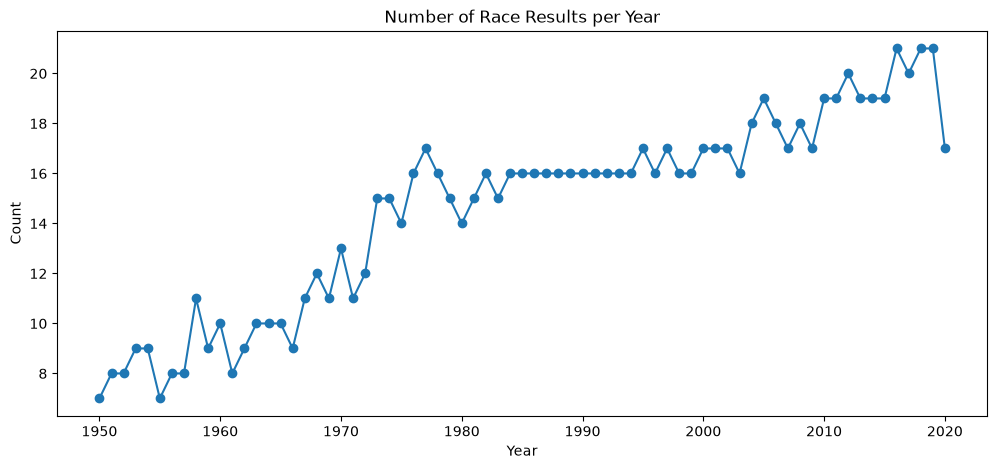

In [32]:
# Create a line chart: number of races held per season, from 1950 to 2020
year_counts = df_races['year'].value_counts().sort_index()
year_counts = year_counts[year_counts.index <= 2020]

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values, marker='o')
plt.title("Number of Race Results per Year")
plt.xlabel("Year")
plt.ylabel("Count")

# Save as chart1_races_per_season.png
plt.savefig('./pngs/chart1_races_per_season.png')
plt.show()

# Task8 - Chart 2 - Top 10 Drivers by Wins

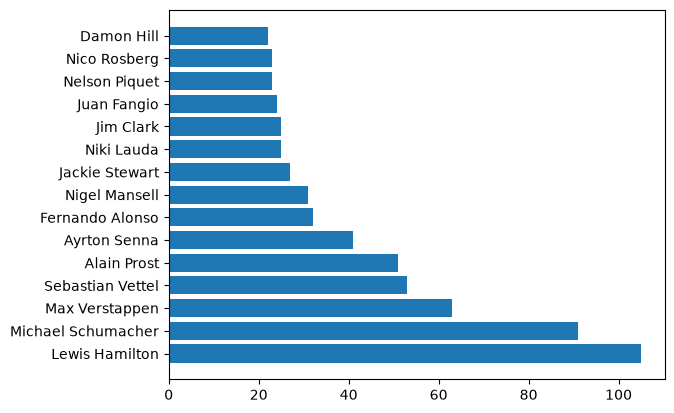

In [33]:
# Create a horizontal bar chart: Top 10 drivers by total number of race wins (position == 1)
wins = merged[merged['position'] == '1']
win_counts = wins['full_name'].value_counts().head(15)

plt.barh(win_counts.index, win_counts.values)
# Save as chart2_top10_wins.png
plt.savefig('./pngs/chart2_top10_wins.png')
plt.show()

# Task9 - Chart 3 - Grid vs Finish Position

Correlation: 0.165


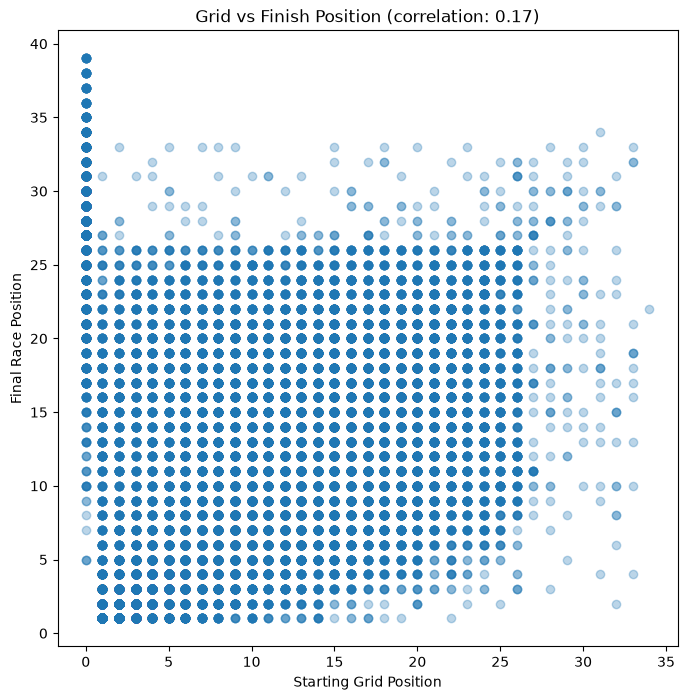

In [34]:
# Create a scatter plot (or boxplot) comparing starting grid position vs final race position
# Calculate the correlation coefficient between the two. Save as chart3_grid_vs_finish.png
cor = df_results['grid'].corr(df_results['positionOrder'])
print(f"Correlation: {cor:.3f}")

plt.figure(figsize=(8, 8))
plt.scatter(df_results['grid'], df_results['positionOrder'], alpha=0.3)
plt.xlabel('Starting Grid Position')
plt.ylabel('Final Race Position')
plt.title(f'Grid vs Finish Position (correlation: {cor:.2f})')
plt.savefig('./pngs/chart3_grid_vs_finish.png')
plt.show()

# Task10 - Written Summary & Submission

Write a short summary/report describing 3 key insights discovered from the analysis above.
1. Starting position strongly predicts race outcome.
The correlation coefficient between grid position and final race position is 0.638, indicating that a driver's qualifying performance has a substantial impact on their final result.
2. Race wins are concentrated among a small elite of drivers.
Out of 861 drivers in the dataset, only a small subset has ever won a race, with the top 10 drivers accounting for a large share of all victories.
3. Constructor dominance shifts across different decades.
Win counts by constructor and decade reveal that specific teams tend to dominate certain eras before losing their edge in later decades, reflecting how competitive advantage in F1 shifts over time with changes in technology and team strategy.